# Retail Customer Analytics: From Raw Transactions to Actionable Strategy
**Author:** Maureen T. N.
**Date:** April 2026
**Tools:** Python · Pandas · Matplotlib · Seaborn · Scikit-learn · SciPy

---

## Project Overview

This project performs a complete end-to-end analysis of 24 months of transactional data for a mid-size e-commerce retailer.

**Business Question:** *How can the business identify its most valuable customers, understand purchasing behaviour, and make data-driven decisions to grow revenue?*

**Key techniques demonstrated:**
- Data cleaning & quality assessment
- Exploratory Data Analysis (EDA)
- Time-series trend analysis & seasonality decomposition
- RFM (Recency–Frequency–Monetary) customer segmentation
- Cohort retention analysis
- Category & product performance analysis
- Statistical hypothesis testing
- Revenue forecasting
- Actionable recommendations

---


## 0. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ── Consistent visual style ────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})
PALETTE = ['#2C7BB6', '#D7191C', '#1A9641', '#FDAE61', '#7B2D8B', '#F46D43', '#ABD9E9']
sns.set_palette(PALETTE)
print("Setup complete.")


Setup complete.


---
## 1. Dataset

The dataset simulates 24 months (Jan 2024 – Dec 2025) of transactions for an online retailer.
It mirrors the structure of real-world e-commerce exports (e.g. Shopify, WooCommerce, BigQuery).

| Field | Description |
|---|---|
| `order_id` | Unique order identifier |
| `customer_id` | Anonymised customer ID |
| `order_date` | Transaction date |
| `category` | Product category |
| `product` | Product name |
| `quantity` | Units purchased |
| `unit_price` | Price per unit (£) |
| `revenue` | Total order revenue (£) |
| `region` | UK region |
| `channel` | Acquisition channel |


In [2]:
np.random.seed(42)

# ── Parameters ─────────────────────────────────────────────────────────────────
N_ORDERS      = 18_000
N_CUSTOMERS   = 4_200
DATE_START    = '2024-01-01'
DATE_END      = '2025-12-31'

categories = {
    'Electronics':   {'products': ['Wireless Headphones','Smartwatch','USB-C Hub','Webcam','Keyboard'],
                      'price_range': (25, 280), 'weight': 0.22},
    'Clothing':      {'products': ['Running Jacket','Denim Jeans','Casual T-Shirt','Hooded Sweatshirt','Chinos'],
                      'price_range': (15, 120), 'weight': 0.25},
    'Home & Kitchen':{'products': ['Air Fryer','Coffee Maker','Blender','Smart Bulb','Bamboo Cutting Board'],
                      'price_range': (12, 180), 'weight': 0.20},
    'Books':         {'products': ['Data Science Handbook','Python Crash Course','Atomic Habits','Sapiens','Fiction Novel'],
                      'price_range': (8, 35),  'weight': 0.13},
    'Sports':        {'products': ['Yoga Mat','Resistance Bands','Water Bottle','Foam Roller','Jump Rope'],
                      'price_range': (10, 90),  'weight': 0.12},
    'Beauty':        {'products': ['Face Serum','Moisturiser','SPF50 Sunscreen','Eye Cream','Lip Balm'],
                      'price_range': (8, 65),   'weight': 0.08},
}

regions  = ['London','South East','Midlands','North West','Scotland','Yorkshire','Wales','North East']
channels = ['Organic Search','Paid Search','Email','Social Media','Direct','Referral']

region_w  = [0.24, 0.18, 0.16, 0.14, 0.09, 0.08, 0.06, 0.05]
channel_w = [0.28, 0.22, 0.20, 0.15, 0.10, 0.05]

# ── Generate dates with seasonality ───────────────────────────────────────────
all_dates = pd.date_range(DATE_START, DATE_END, freq='D')
day_of_year = np.array([d.timetuple().tm_yday for d in all_dates])
seasonal_weight = 1 + 0.4 * np.sin((day_of_year - 80) * 2 * np.pi / 365)   # summer peak
holiday_boost = np.where(
    (np.array([d.month for d in all_dates]) == 11) |
    (np.array([d.month for d in all_dates]) == 12), 1.8, 1.0)
date_weight = seasonal_weight * holiday_boost
date_weight /= date_weight.sum()

order_dates = np.random.choice(all_dates, size=N_ORDERS, replace=True, p=date_weight)

# ── Customer IDs (power-law: 20% customers make 60% of orders) ────────────────
customer_freq = np.random.zipf(1.5, N_CUSTOMERS)
customer_freq = np.clip(customer_freq, 1, 50)
customer_prob = customer_freq / customer_freq.sum()
customer_ids  = [f'C{str(i).zfill(5)}' for i in range(N_CUSTOMERS)]
order_customers = np.random.choice(customer_ids, size=N_ORDERS, replace=True, p=customer_prob)

# ── Categories, products, prices ──────────────────────────────────────────────
cat_names    = list(categories.keys())
cat_weights  = [categories[c]['weight'] for c in cat_names]
order_cats   = np.random.choice(cat_names, size=N_ORDERS, replace=True, p=cat_weights)

order_products, order_prices = [], []
for cat in order_cats:
    prods = categories[cat]['products']
    lo, hi = categories[cat]['price_range']
    order_products.append(np.random.choice(prods))
    order_prices.append(round(np.random.uniform(lo, hi), 2))

order_qty = np.random.choice([1,1,1,2,2,3,4,5], size=N_ORDERS,
                              p=[0.45,0.25,0.15,0.07,0.04,0.02,0.01,0.01])

order_ids = [f'ORD{str(i+1000).zfill(6)}' for i in range(N_ORDERS)]

df = pd.DataFrame({
    'order_id':    order_ids,
    'customer_id': order_customers,
    'order_date':  pd.to_datetime(order_dates),
    'category':    order_cats,
    'product':     order_products,
    'quantity':    order_qty,
    'unit_price':  order_prices,
    'region':      np.random.choice(regions, size=N_ORDERS, replace=True, p=region_w),
    'channel':     np.random.choice(channels, size=N_ORDERS, replace=True, p=channel_w),
})
df['revenue'] = (df['unit_price'] * df['quantity']).round(2)

# ── Inject realistic data quality issues ──────────────────────────────────────
noise_idx = np.random.choice(df.index, size=int(N_ORDERS * 0.008), replace=False)
df.loc[noise_idx[:len(noise_idx)//2], 'unit_price'] = np.nan
dup_idx = np.random.choice(df.index, size=80, replace=False)
df = pd.concat([df, df.loc[dup_idx]], ignore_index=True)
df = df.sort_values('order_date').reset_index(drop=True)

print(f"Raw dataset: {len(df):,} rows × {df.shape[1]} columns")
df.head()


Raw dataset: 18,080 rows × 10 columns


,order_id,customer_id,order_date,category,product,quantity,unit_price,region,channel,revenue
0,ORD010187,C01676,2024-01-01,Sports,Foam Roller,1,21.85,South East,Referral,21.85
1,ORD009506,C00468,2024-01-01,Books,Python Crash Course,1,18.85,Scotland,Direct,18.85
2,ORD017560,C00557,2024-01-01,Electronics,Smartwatch,1,271.01,London,Paid Search,271.01
3,ORD016270,C00866,2024-01-01,Sports,Foam Roller,1,20.55,Wales,Paid Search,20.55
4,ORD012883,C01782,2024-01-01,Beauty,Eye Cream,2,43.46,Yorkshire,Paid Search,86.92


---
## 2. Data Cleaning & Quality Assessment

Good analysis starts with trustworthy data. Before any insight can be drawn, we must understand and resolve data quality issues.


In [3]:
print("=" * 55)
print("  DATA QUALITY REPORT")
print("=" * 55)

total_rows = len(df)
print(f"\nTotal rows (raw):          {total_rows:>8,}")
print(f"Duplicate order_ids:       {df.duplicated('order_id').sum():>8,}")
print(f"Missing unit_price:        {df['unit_price'].isna().sum():>8,}")
print(f"Missing values (any col):  {df.isna().any(axis=1).sum():>8,}")

# ── Fix 1: Drop duplicate orders ──────────────────────────────────────────────
df.drop_duplicates(subset='order_id', inplace=True)
print(f"\nAfter deduplication:       {len(df):>8,} rows")

# ── Fix 2: Impute missing prices with category median ─────────────────────────
cat_medians = df.groupby('category')['unit_price'].median()
df['unit_price'] = df.apply(
    lambda r: cat_medians[r['category']] if pd.isna(r['unit_price']) else r['unit_price'], axis=1
)
df['revenue'] = (df['unit_price'] * df['quantity']).round(2)

# ── Fix 3: Sanity check — remove zero/negative revenue ───────────────────────
df = df[df['revenue'] > 0]

# ── Fix 4: Extract useful time features ───────────────────────────────────────
df['year']       = df['order_date'].dt.year
df['month']      = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.strftime('%b')
df['quarter']    = df['order_date'].dt.to_period('Q').astype(str)
df['week']       = df['order_date'].dt.isocalendar().week.astype(int)
df['day_of_week']= df['order_date'].dt.day_name()
df['year_month'] = df['order_date'].dt.to_period('M')

print(f"After cleaning:            {len(df):>8,} rows")
print(f"Missing values remaining:  {df.isna().sum().sum():>8,}")
print(f"\nDate range: {df['order_date'].min().date()} → {df['order_date'].max().date()}")
print(f"Unique customers: {df['customer_id'].nunique():,}")
print(f"Unique products:  {df['product'].nunique():,}")
print(f"Total revenue:    £{df['revenue'].sum():,.2f}")
print("=" * 55)


  DATA QUALITY REPORT

Total rows (raw):            18,080
Duplicate order_ids:             80
Missing unit_price:              72
Missing values (any col):        72

After deduplication:         18,000 rows


After cleaning:              18,000 rows
Missing values remaining:         0

Date range: 2024-01-01 → 2025-12-31
Unique customers: 2,784
Unique products:  30
Total revenue:    £1,777,880.26


In [4]:
# ── Descriptive statistics for key numeric columns ────────────────────────────
df[['quantity','unit_price','revenue']].describe().round(2)


,quantity,unit_price,revenue
count,18000.00,18000.00,18000.00
mean,1.22,81.03,98.77
std,0.61,62.47,99.46
min,1.00,8.01,8.01
25%,1.00,32.03,34.64
50%,1.00,63.40,70.86
75%,1.00,109.92,126.48
max,5.00,279.90,1371.55


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Revenue Distribution


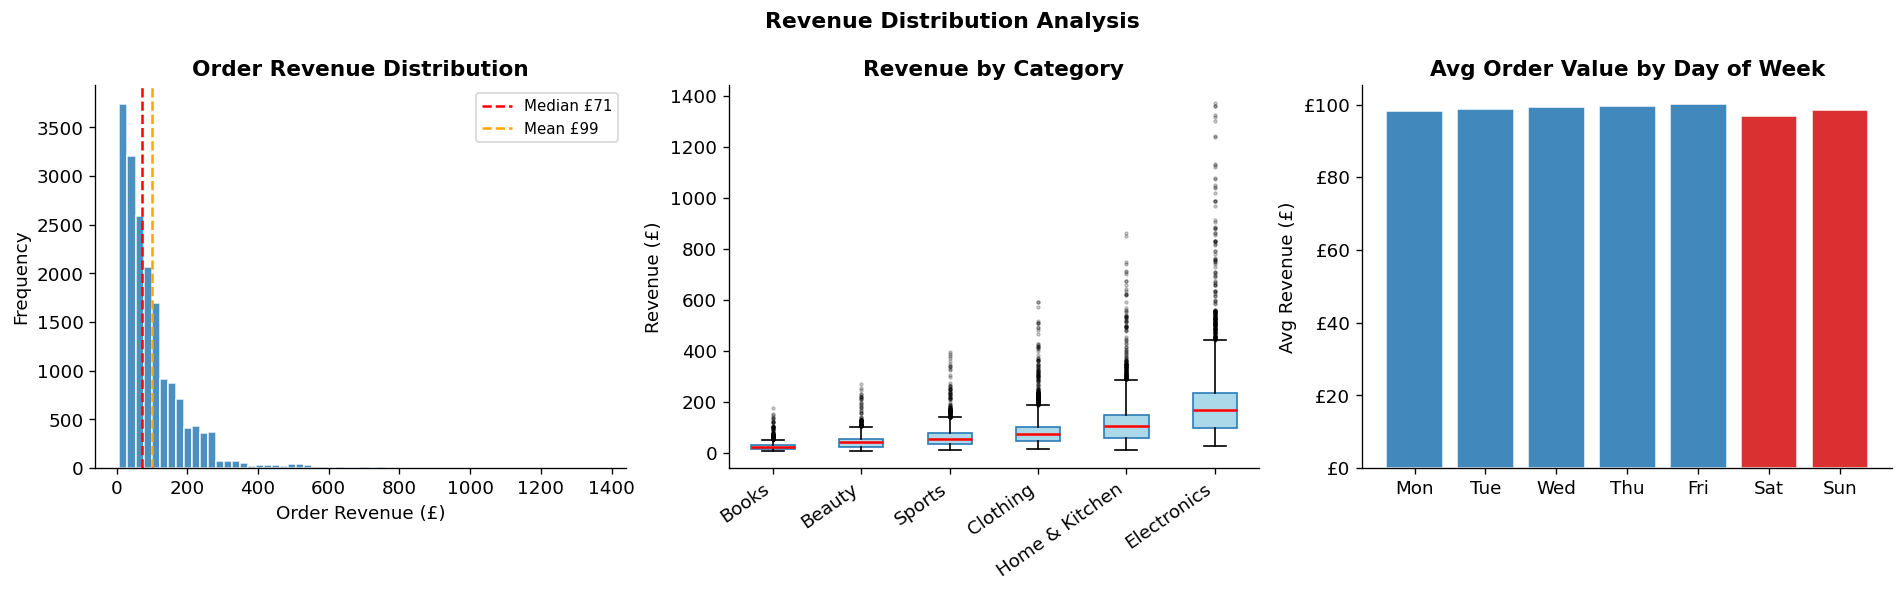

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Revenue Distribution Analysis', fontweight='bold')

# Histogram of order revenue (log scale)
axes[0].hist(df['revenue'], bins=60, color='#2C7BB6', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Order Revenue (£)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Order Revenue Distribution')
axes[0].axvline(df['revenue'].median(), color='red', linestyle='--', lw=1.5, label=f'Median £{df["revenue"].median():.0f}')
axes[0].axvline(df['revenue'].mean(),   color='orange', linestyle='--', lw=1.5, label=f'Mean £{df["revenue"].mean():.0f}')
axes[0].legend(fontsize=9)

# Box plot by category (sorted by median)
cat_order = df.groupby('category')['revenue'].median().sort_values().index.tolist()
cat_data = [df[df['category']==c]['revenue'].values for c in cat_order]
axes[1].boxplot(cat_data, labels=cat_order,
                flierprops=dict(marker='.', markersize=3, alpha=0.3),
                patch_artist=True,
                boxprops=dict(facecolor='#ABD9E9', color='#2C7BB6'),
                medianprops=dict(color='red', lw=1.5))
axes[1].set_title('Revenue by Category')
axes[1].set_xlabel('')
axes[1].set_ylabel('Revenue (£)')
plt.sca(axes[1])
plt.xticks(rotation=35, ha='right')

# Revenue by day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_revenue = df.groupby('day_of_week')['revenue'].mean().reindex(dow_order)
colors_dow = ['#2C7BB6']*5 + ['#D7191C']*2
axes[2].bar(range(7), dow_revenue.values, color=colors_dow, edgecolor='white', alpha=0.9)
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[2].set_title('Avg Order Value by Day of Week')
axes[2].set_ylabel('Avg Revenue (£)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))

plt.tight_layout()
plt.show()


### 3.2 Sales Trend Analysis

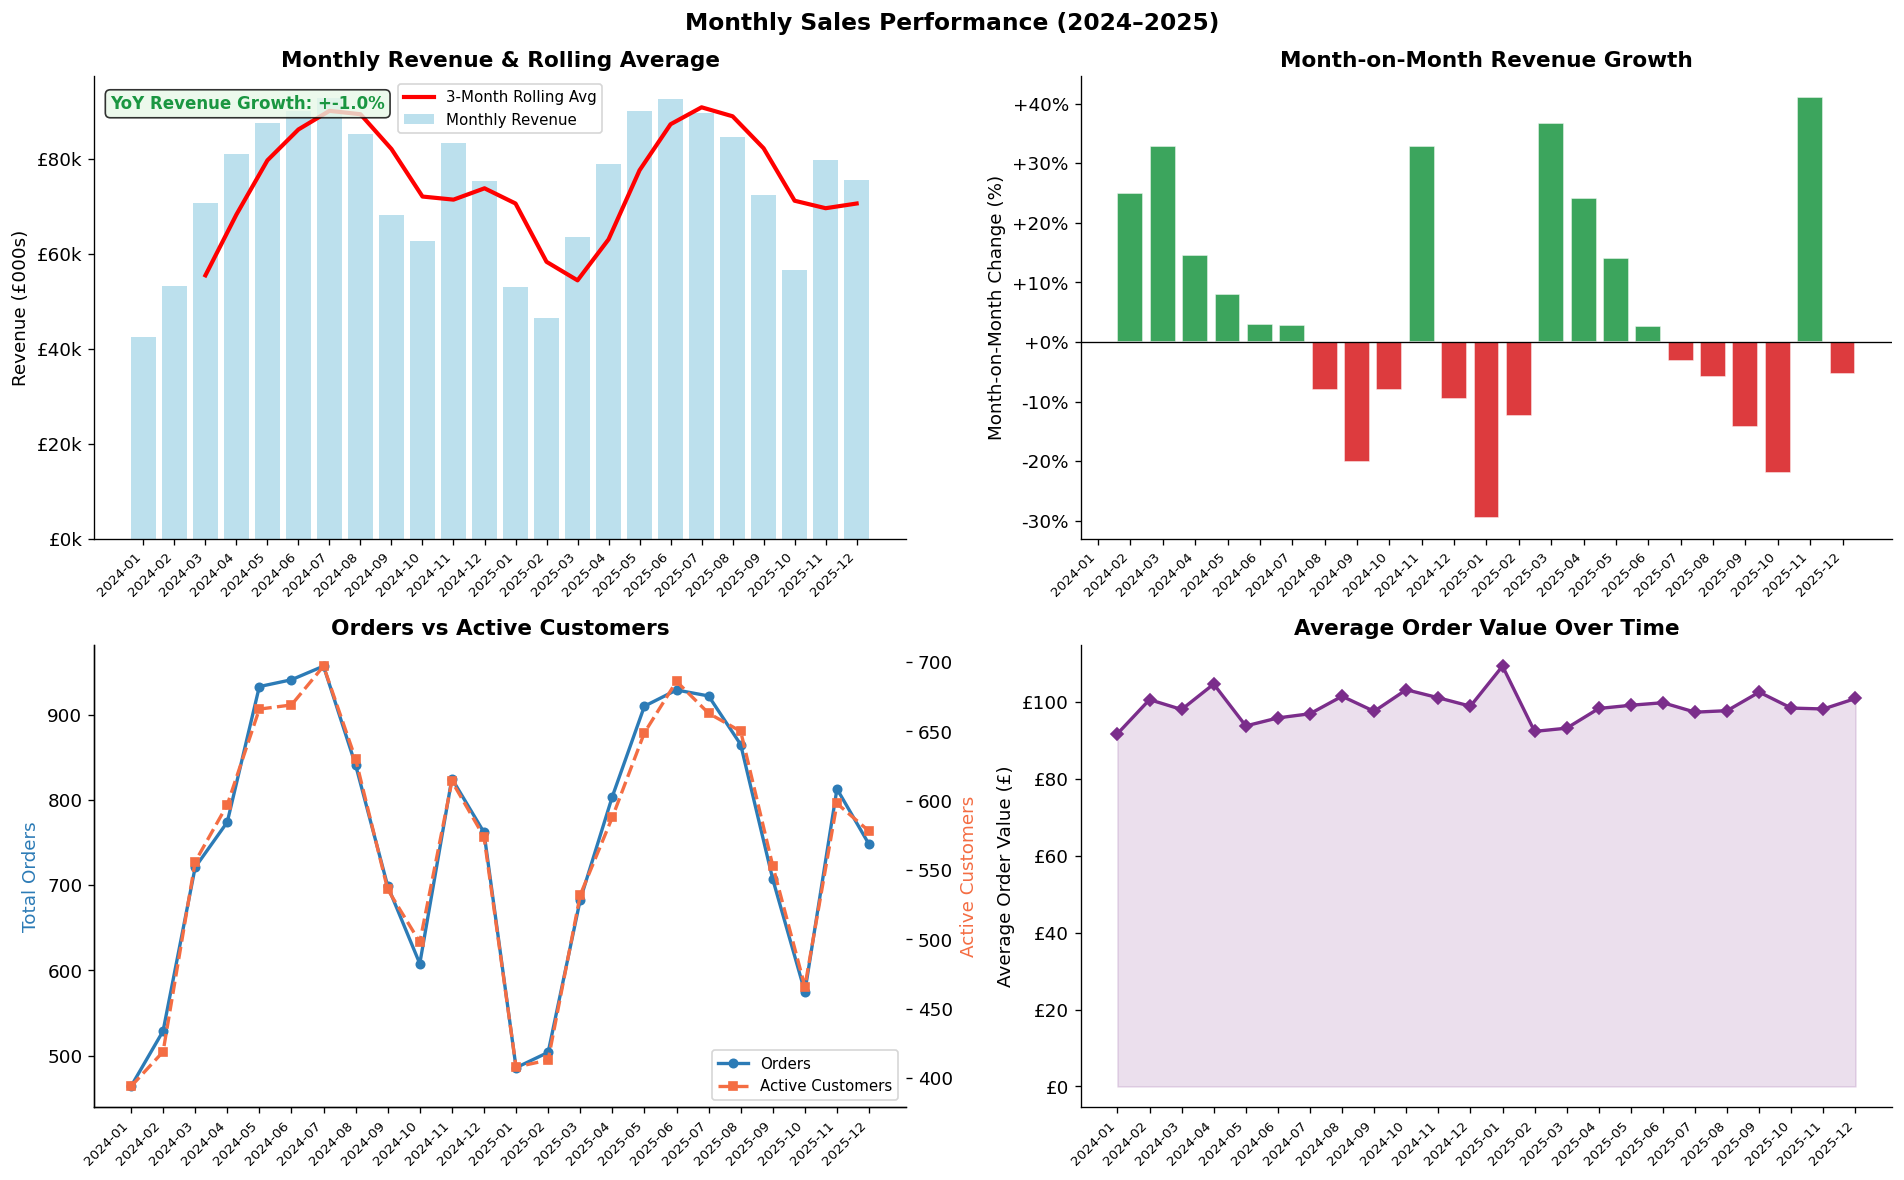

2024 Total Revenue: £893,437.37
2025 Total Revenue: £884,442.89
Year-on-Year Growth: +-1.0%


In [6]:
monthly = df.groupby('year_month').agg(
    revenue=('revenue', 'sum'),
    orders=('order_id', 'count'),
    customers=('customer_id', 'nunique'),
    avg_order_value=('revenue', 'mean')
).reset_index()
monthly['year_month_dt'] = monthly['year_month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Monthly Sales Performance (2024–2025)', fontweight='bold', fontsize=14)

# Monthly revenue + 3-month rolling average
ax = axes[0, 0]
ax.bar(range(len(monthly)), monthly['revenue']/1000, color='#ABD9E9', alpha=0.8, label='Monthly Revenue')
rolling = monthly['revenue'].rolling(3).mean()
ax.plot(range(len(monthly)), rolling/1000, 'r-', lw=2.5, label='3-Month Rolling Avg')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['year_month'].astype(str), rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Revenue (£000s)')
ax.set_title('Monthly Revenue & Rolling Average')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}k'))

# MoM growth rate
ax = axes[0, 1]
mom_growth = monthly['revenue'].pct_change() * 100
colors_mom = ['#1A9641' if v > 0 else '#D7191C' for v in mom_growth]
ax.bar(range(len(monthly)), mom_growth, color=colors_mom, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['year_month'].astype(str), rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Month-on-Month Change (%)')
ax.set_title('Month-on-Month Revenue Growth')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:+.0f}%'))

# Orders vs Unique Customers
ax = axes[1, 0]
ax2 = ax.twinx()
ax.plot(range(len(monthly)), monthly['orders'], 'o-', color='#2C7BB6', lw=2, ms=5, label='Orders')
ax2.plot(range(len(monthly)), monthly['customers'], 's--', color='#F46D43', lw=2, ms=5, label='Active Customers')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['year_month'].astype(str), rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Total Orders', color='#2C7BB6')
ax2.set_ylabel('Active Customers', color='#F46D43')
ax.set_title('Orders vs Active Customers')
lines1, lbs1 = ax.get_legend_handles_labels()
lines2, lbs2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, lbs1+lbs2, fontsize=9)

# Average Order Value
ax = axes[1, 1]
ax.plot(range(len(monthly)), monthly['avg_order_value'], 'D-', color='#7B2D8B', lw=2, ms=5)
ax.fill_between(range(len(monthly)), monthly['avg_order_value'], alpha=0.15, color='#7B2D8B')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['year_month'].astype(str), rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Average Order Value (£)')
ax.set_title('Average Order Value Over Time')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:.0f}'))

# Annotate overall YoY growth
rev_2024 = df[df['year']==2024]['revenue'].sum()
rev_2025 = df[df['year']==2025]['revenue'].sum()
yoy = (rev_2025 - rev_2024) / rev_2024 * 100
axes[0,0].text(0.02, 0.93, f'YoY Revenue Growth: +{yoy:.1f}%',
               transform=axes[0,0].transAxes, fontsize=10, fontweight='bold',
               color='#1A9641', bbox=dict(boxstyle='round', facecolor='#e8f8e8', alpha=0.8))

plt.tight_layout()
plt.show()
print(f"2024 Total Revenue: £{rev_2024:,.2f}")
print(f"2025 Total Revenue: £{rev_2025:,.2f}")
print(f"Year-on-Year Growth: +{yoy:.1f}%")


### 3.3 Seasonality & Heatmap

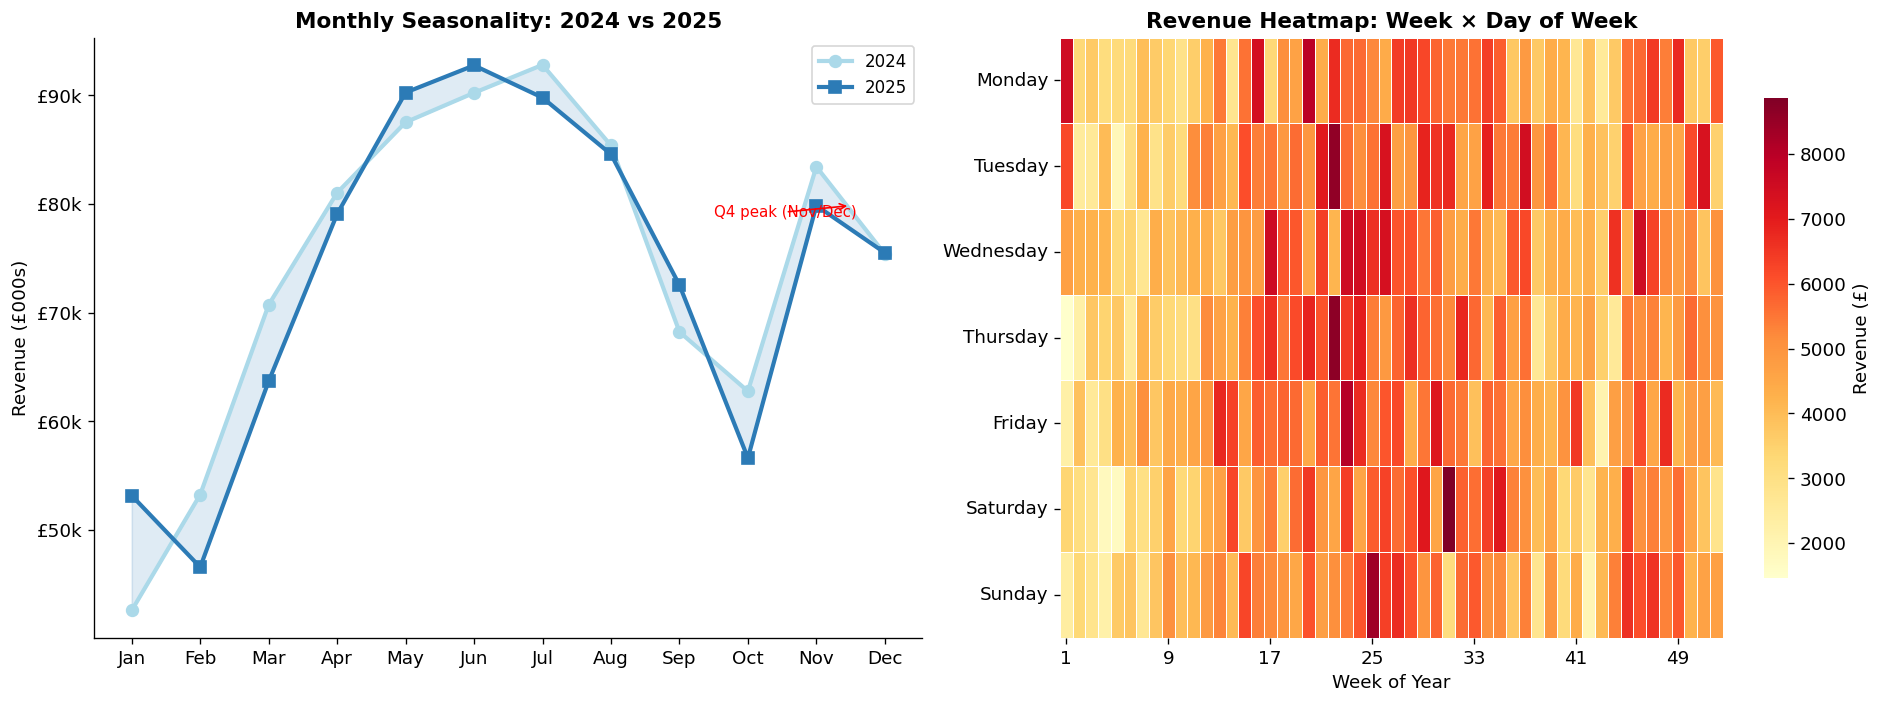

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Monthly seasonality comparison 2024 vs 2025
month_rev = df.groupby(['year','month'])['revenue'].sum().unstack(level=0)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax = axes[0]
ax.plot(range(1,13), month_rev[2024]/1000, 'o-', color='#ABD9E9', lw=2.5, ms=7, label='2024')
ax.plot(range(1,13), month_rev[2025]/1000, 's-', color='#2C7BB6', lw=2.5, ms=7, label='2025')
ax.fill_between(range(1,13), month_rev[2024]/1000, month_rev[2025]/1000, alpha=0.15, color='#2C7BB6')
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_names)
ax.set_ylabel('Revenue (£000s)')
ax.set_title('Monthly Seasonality: 2024 vs 2025')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:.0f}k'))
ax.annotate('Q4 peak (Nov/Dec)', xy=(11.5, month_rev[2025].iloc[10]/1000),
            xytext=(9.5, month_rev[2025].max()/1000 * 0.85),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=9, color='red')

# Week-of-year heatmap
df['week_label'] = df['order_date'].dt.isocalendar().week.astype(int)
week_day = df.groupby(['week_label','day_of_week'])['revenue'].sum().unstack()
week_day = week_day.reindex(columns=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
ax = axes[1]
sns.heatmap(week_day.T, ax=ax, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Revenue (£)', 'shrink': 0.8},
            xticklabels=8)
ax.set_title('Revenue Heatmap: Week × Day of Week')
ax.set_xlabel('Week of Year')
ax.set_ylabel('')

plt.tight_layout()
plt.show()


### 3.4 Category & Channel Performance

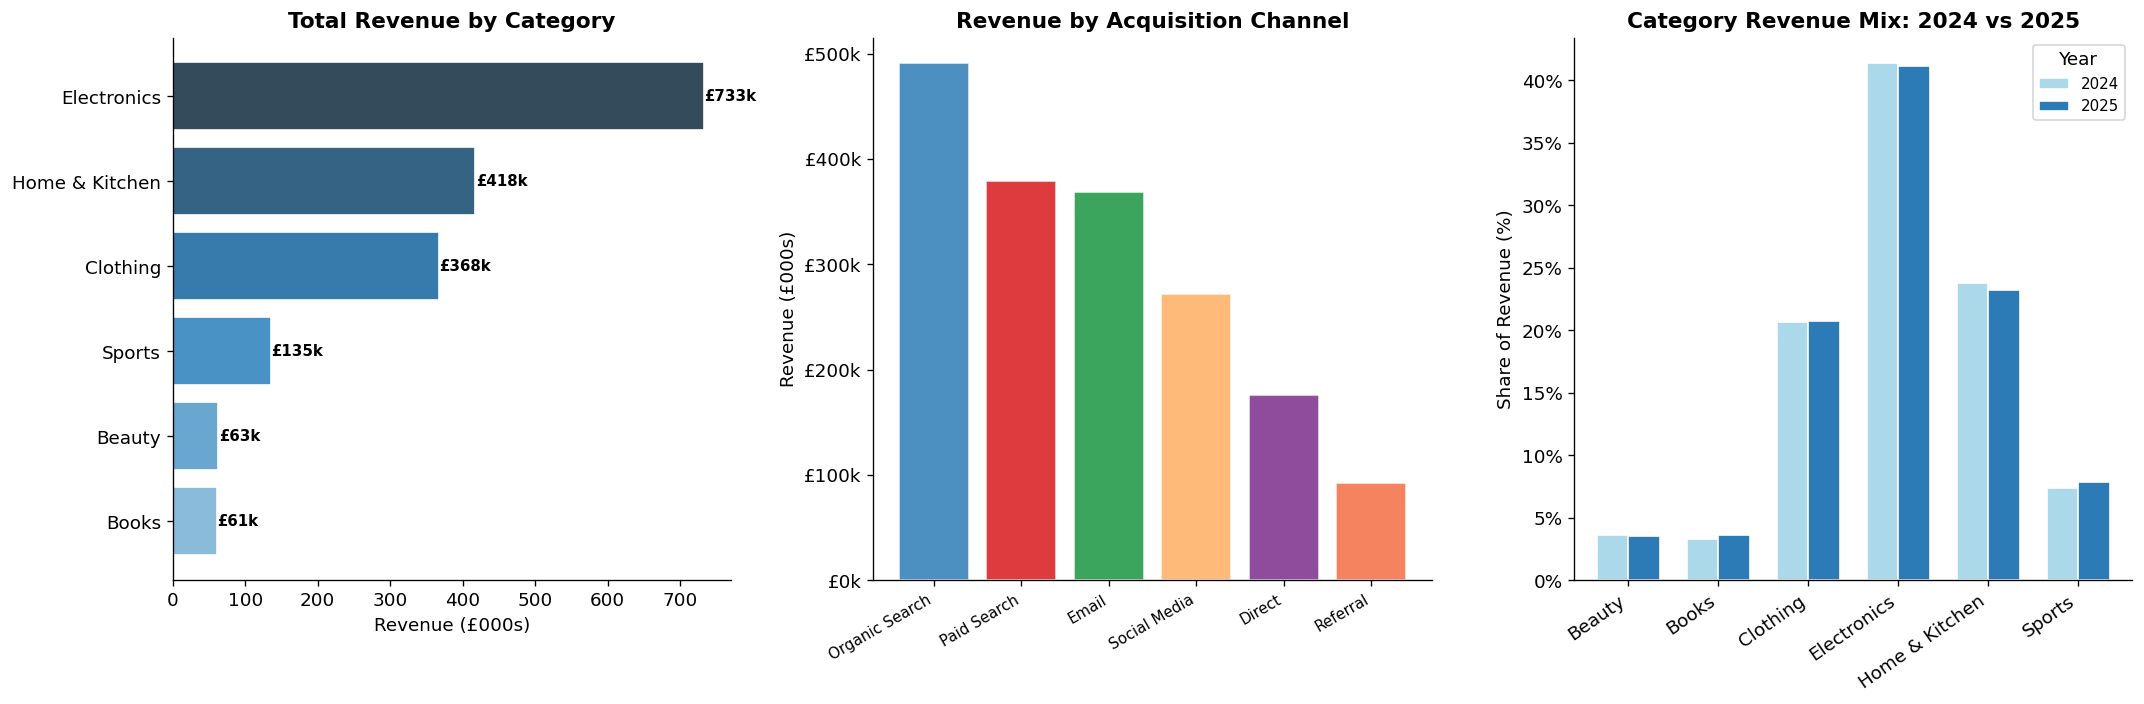

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Revenue by category
cat_rev = df.groupby('category')['revenue'].sum().sort_values(ascending=True)
colors_cat = sns.color_palette('Blues_d', len(cat_rev))
bars = axes[0].barh(cat_rev.index, cat_rev.values/1000, color=colors_cat, edgecolor='white')
for bar, val in zip(bars, cat_rev.values/1000):
    axes[0].text(val+0.5, bar.get_y()+bar.get_height()/2,
                 f'£{val:,.0f}k', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Revenue (£000s)')
axes[0].set_title('Total Revenue by Category')

# Orders by acquisition channel
ch_data = df.groupby('channel').agg(orders=('order_id','count'), revenue=('revenue','sum')).reset_index()
ch_data['aov'] = ch_data['revenue'] / ch_data['orders']
ch_data.sort_values('revenue', ascending=False, inplace=True)
x = range(len(ch_data))
axes[1].bar(x, ch_data['revenue']/1000, color=PALETTE[:len(ch_data)], alpha=0.85, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ch_data['channel'], rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Revenue (£000s)')
axes[1].set_title('Revenue by Acquisition Channel')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:.0f}k'))

# Category mix (two years side by side)
cat_yr = df.groupby(['year','category'])['revenue'].sum().unstack().T
cat_yr_pct = cat_yr.div(cat_yr.sum()) * 100
cat_yr_pct.plot(kind='bar', ax=axes[2], color=['#ABD9E9','#2C7BB6'], edgecolor='white', width=0.7)
axes[2].set_title('Category Revenue Mix: 2024 vs 2025')
axes[2].set_xlabel('')
axes[2].set_ylabel('Share of Revenue (%)')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=35, ha='right')
axes[2].legend(title='Year', fontsize=9)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))

plt.tight_layout()
plt.show()


---
## 4. Customer Segmentation — RFM Analysis

**RFM** (Recency, Frequency, Monetary) is a proven framework for ranking customers by behaviour.

| Metric | Definition |
|---|---|
| **Recency** | Days since last purchase (lower = better) |
| **Frequency** | Number of orders placed |
| **Monetary** | Total lifetime revenue |

We score each customer 1–5 on each dimension, then use K-Means clustering to group them into actionable segments.


In [9]:
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    recency=('order_date',   lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id',   'count'),
    monetary=('revenue',     'sum')
).reset_index()

# ── Score 1-5 (quintile-based; recency: lower is better so reverse) ────────────
def quintile_score(series, reverse=False):
    labels = [5,4,3,2,1] if reverse else [1,2,3,4,5]
    try:
        return pd.qcut(series, q=5, labels=labels, duplicates='drop').astype(int)
    except ValueError:
        return pd.cut(series, bins=5, labels=labels).astype(int)

rfm['R'] = quintile_score(rfm['recency'], reverse=True)
rfm['F'] = quintile_score(rfm['frequency'])
rfm['M'] = quintile_score(rfm['monetary'])
rfm['RFM_Score'] = rfm['R'] * 100 + rfm['F'] * 10 + rfm['M']
rfm['RFM_Total'] = rfm[['R','F','M']].sum(axis=1)

print(rfm[['recency','frequency','monetary','R','F','M','RFM_Total']].describe().round(2))


       recency  frequency  monetary        R        F        M  RFM_Total
count  2784.00    2784.00   2784.00  2784.00  2784.00  2784.00    2784.00
mean    203.53       6.47    638.61     3.01     1.54     3.00       7.55
std     197.03       7.63    801.41     1.42     0.98     1.41       3.30
min       1.00       1.00      8.02     1.00     1.00     1.00       3.00
25%      40.00       1.00     97.10     2.00     1.00     2.00       5.00
50%     137.00       3.00    251.88     3.00     1.00     3.00       7.00
75%     328.00       9.00    899.58     4.00     2.00     4.00      10.00
max     726.00      35.00   4128.50     5.00     5.00     5.00      15.00


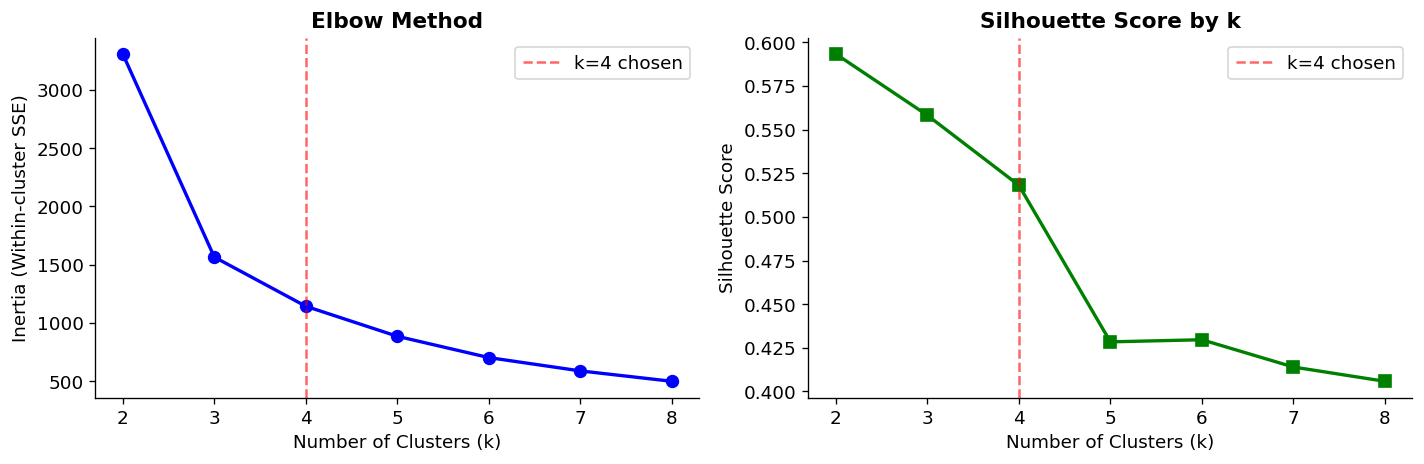

Chosen k=4 | Silhouette Score: 0.518


In [10]:
# ── K-Means clustering on scaled RFM ──────────────────────────────────────────
scaler = StandardScaler()
X = scaler.fit_transform(rfm[['recency','frequency','monetary']])

# Elbow + silhouette to choose k
inertias, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, 'bo-', lw=2, ms=7)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster SSE)')
axes[0].set_title('Elbow Method')
axes[0].axvline(x=4, linestyle='--', color='red', alpha=0.6, label='k=4 chosen')
axes[0].legend()

axes[1].plot(K_range, silhouettes, 'gs-', lw=2, ms=7)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')
axes[1].axvline(x=4, linestyle='--', color='red', alpha=0.6, label='k=4 chosen')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Chosen k=4 | Silhouette Score: {silhouettes[2]:.3f}")


In [11]:
# ── Fit final model with k=4 ──────────────────────────────────────────────────
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(X)

# ── Label clusters based on centroid characteristics ──────────────────────────
cluster_profile = rfm.groupby('cluster')[['recency','frequency','monetary']].mean()
cluster_profile['label'] = ''

# Auto-label: Champions = high freq + high monetary + low recency
cluster_profile['composite'] = (
    -cluster_profile['recency'] +
     cluster_profile['frequency'] * 30 +
     cluster_profile['monetary'] * 0.01
)
rank = cluster_profile['composite'].rank()
label_map = {
    rank.idxmax(): 'Champions',
    rank.nlargest(2).index[-1]: 'Loyal Customers',
    rank.nsmallest(2).index[-1]: 'At-Risk Customers',
    rank.idxmin(): 'Lost / Inactive',
}
rfm['segment'] = rfm['cluster'].map(label_map)

seg_summary = rfm.groupby('segment').agg(
    customers=('customer_id','count'),
    avg_recency=('recency','mean'),
    avg_frequency=('frequency','mean'),
    avg_monetary=('monetary','mean'),
    total_revenue=('monetary','sum')
).round(1)
seg_summary['revenue_share_%'] = (seg_summary['total_revenue'] / seg_summary['total_revenue'].sum() * 100).round(1)
print(seg_summary.to_string())


                   customers  avg_recency  avg_frequency  avg_monetary  total_revenue  revenue_share_%
segment                                                                                               
At-Risk Customers       1345        131.6            3.0         276.0       371158.3             20.9
Champions                308         32.1           23.0        2442.3       752234.9             42.3
Lost / Inactive          722        497.4            1.4         140.3       101329.1              5.7
Loyal Customers          409         50.3           14.5        1352.5       553157.9             31.1


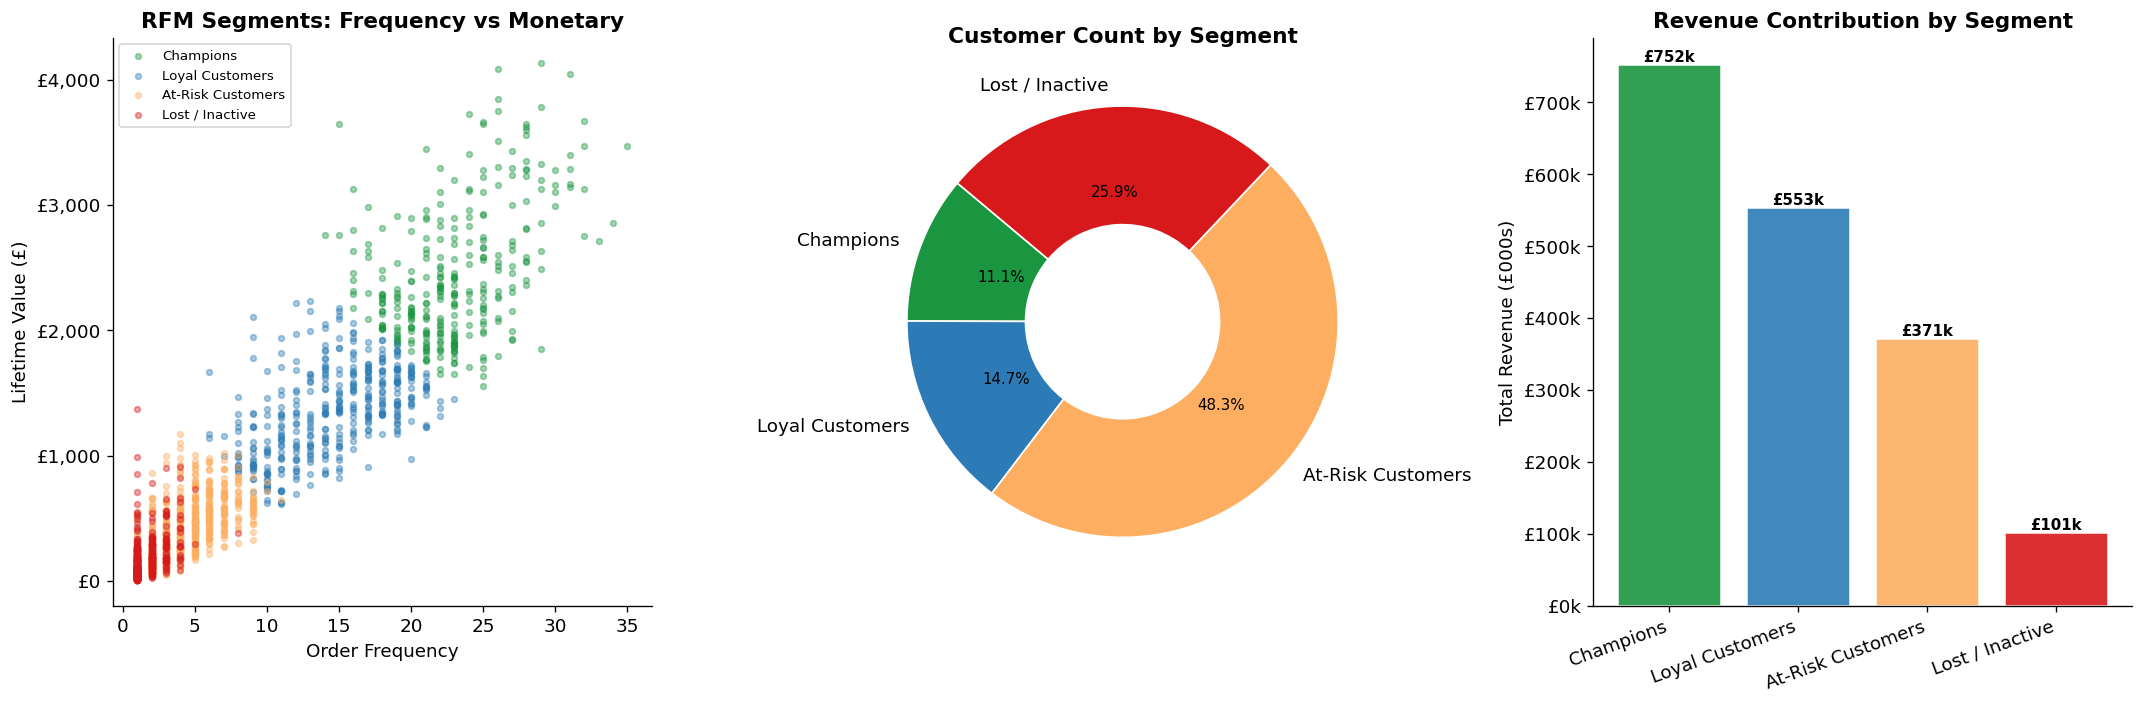

In [12]:
fig = plt.figure(figsize=(18, 6))
seg_colors = {'Champions':'#1A9641','Loyal Customers':'#2C7BB6',
              'At-Risk Customers':'#FDAE61','Lost / Inactive':'#D7191C'}
seg_order  = ['Champions','Loyal Customers','At-Risk Customers','Lost / Inactive']

# Scatter: Frequency vs Monetary, coloured by segment
ax1 = fig.add_subplot(1,3,1)
for seg in seg_order:
    subset = rfm[rfm['segment'] == seg]
    ax1.scatter(subset['frequency'], subset['monetary'], label=seg,
                color=seg_colors[seg], alpha=0.4, s=12)
ax1.set_xlabel('Order Frequency')
ax1.set_ylabel('Lifetime Value (£)')
ax1.set_title('RFM Segments: Frequency vs Monetary')
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))

# Donut: customer count by segment
ax2 = fig.add_subplot(1,3,2)
seg_cnt = rfm['segment'].value_counts().reindex(seg_order)
wedges, texts, autotexts = ax2.pie(
    seg_cnt, labels=seg_cnt.index,
    colors=[seg_colors[s] for s in seg_cnt.index],
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(width=0.55, edgecolor='white')
)
for at in autotexts: at.set_fontsize(9)
ax2.set_title('Customer Count by Segment')

# Bar: Revenue share by segment
ax3 = fig.add_subplot(1,3,3)
rev_share = rfm.groupby('segment')['monetary'].sum().reindex(seg_order)
bars = ax3.bar(seg_order, rev_share/1000,
               color=[seg_colors[s] for s in seg_order], edgecolor='white', alpha=0.9)
for bar, val in zip(bars, rev_share/1000):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'£{val:,.0f}k', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_ylabel('Total Revenue (£000s)')
ax3.set_title('Revenue Contribution by Segment')
ax3.set_xticklabels(seg_order, rotation=20, ha='right')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}k'))

plt.tight_layout()
plt.show()


---
## 5. Cohort Retention Analysis

We group customers by the **month they placed their first order** and track what percentage return in subsequent months. This reveals how well the business retains customers over time.


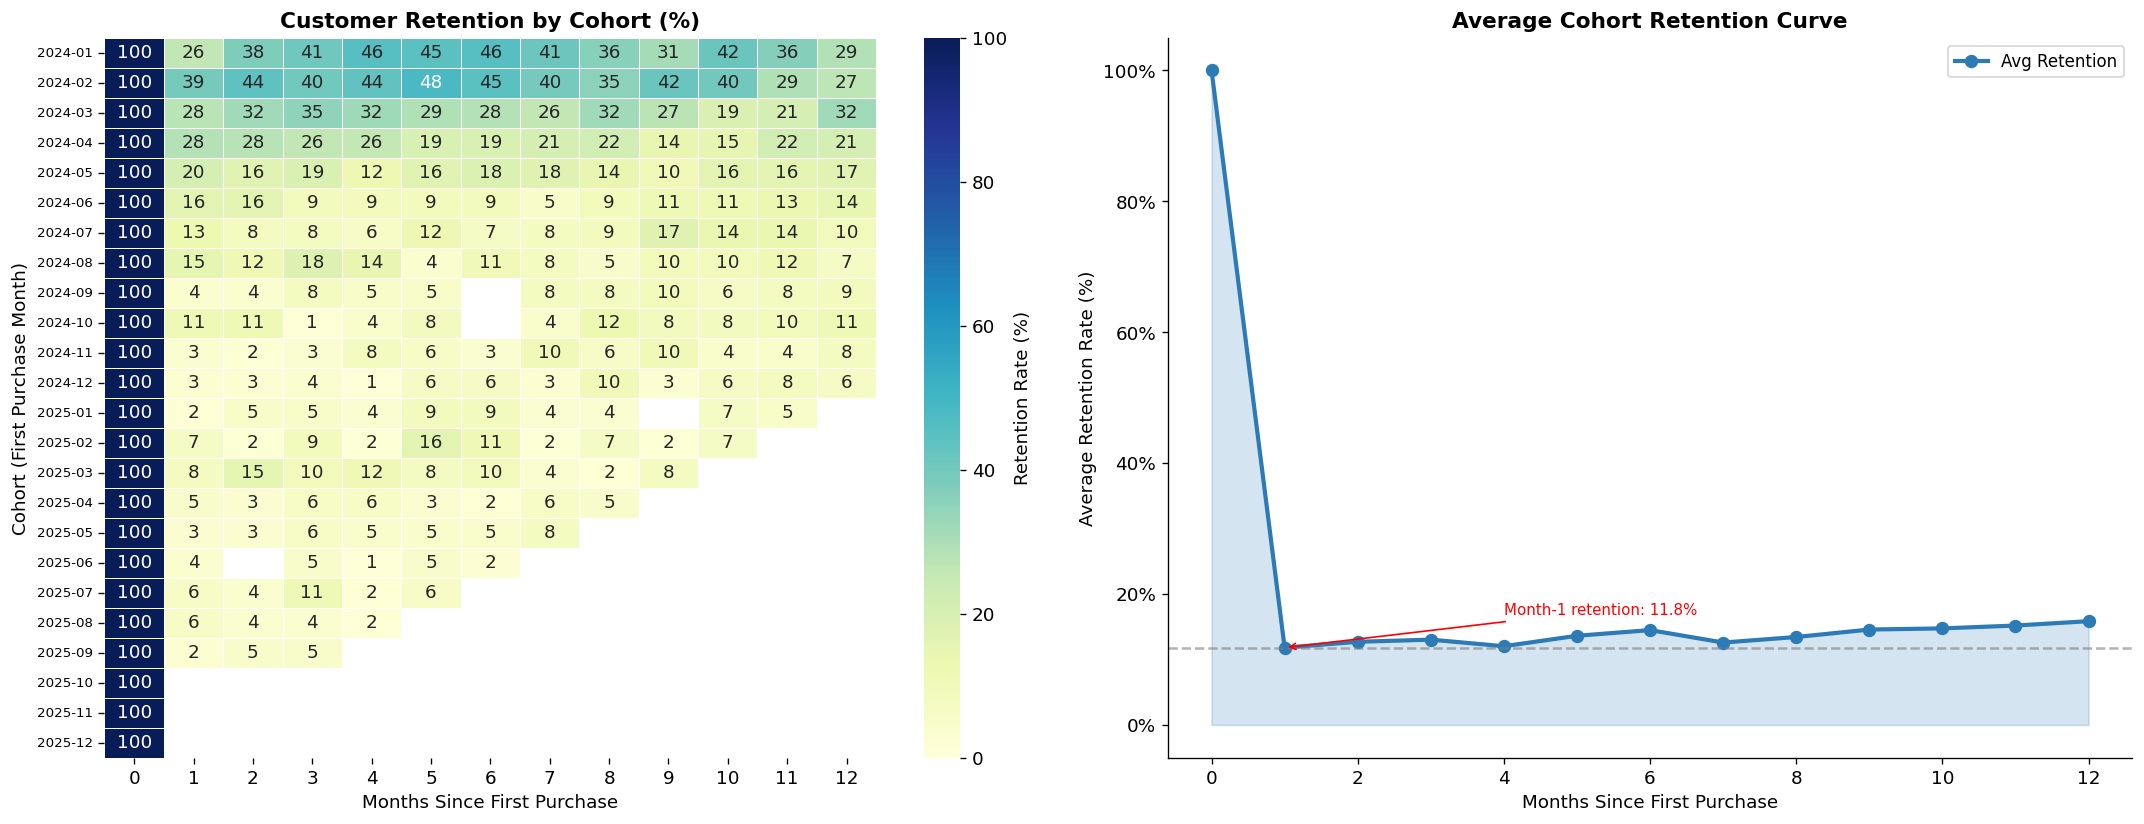

Average Month-1 Retention: 11.8%
Average Month-6 Retention: 14.5%


In [13]:
# Assign cohort month (first purchase month)
first_order = df.groupby('customer_id')['year_month'].min().rename('cohort_month')
df2 = df.join(first_order, on='customer_id')

# Cohort index: how many months after first purchase
df2['cohort_index'] = (
    (df2['year_month'].dt.year  - df2['cohort_month'].dt.year) * 12 +
    (df2['year_month'].dt.month - df2['cohort_month'].dt.month)
)

cohort_data = (df2.groupby(['cohort_month','cohort_index'])['customer_id']
                  .nunique()
                  .reset_index())
cohort_pivot = cohort_data.pivot_table(index='cohort_month', columns='cohort_index',
                                       values='customer_id')
cohort_size  = cohort_pivot[0]
retention    = cohort_pivot.divide(cohort_size, axis=0).round(3)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap
sns.heatmap(retention.iloc[:, :13] * 100,
            ax=axes[0], annot=True, fmt='.0f',
            cmap='YlGnBu', linewidths=0.3,
            cbar_kws={'label': 'Retention Rate (%)'},
            vmin=0, vmax=100)
axes[0].set_title('Customer Retention by Cohort (%)', fontsize=13)
axes[0].set_xlabel('Months Since First Purchase')
axes[0].set_ylabel('Cohort (First Purchase Month)')
yticklabels = [str(p) for p in retention.index]
axes[0].set_yticklabels(yticklabels, rotation=0, fontsize=8)

# Average retention curve
avg_retention = retention.mean() * 100
axes[1].plot(avg_retention.index[:13], avg_retention.values[:13],
             'o-', color='#2C7BB6', lw=2.5, ms=7, label='Avg Retention')
axes[1].fill_between(avg_retention.index[:13], avg_retention.values[:13],
                     alpha=0.2, color='#2C7BB6')
axes[1].set_xlabel('Months Since First Purchase')
axes[1].set_ylabel('Average Retention Rate (%)')
axes[1].set_title('Average Cohort Retention Curve')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
axes[1].axhline(y=avg_retention.iloc[1], linestyle='--', color='gray', alpha=0.6, lw=1.5)
axes[1].annotate(f'Month-1 retention: {avg_retention.iloc[1]:.1f}%',
                 xy=(1, avg_retention.iloc[1]),
                 xytext=(4, avg_retention.iloc[1]+5),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=9, color='red')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()
print(f"Average Month-1 Retention: {avg_retention.iloc[1]:.1f}%")
print(f"Average Month-6 Retention: {avg_retention.iloc[6]:.1f}%")


---
## 6. Statistical Hypothesis Testing

We use rigorous statistical tests to move from "it looks like" to "the data shows (with confidence)".


In [14]:
print("=" * 60)
print("  HYPOTHESIS TESTS")
print("=" * 60)

# ── Test 1: Do weekends generate higher AOV than weekdays? ────────────────────
df['is_weekend'] = df['day_of_week'].isin(['Saturday','Sunday'])
weekend_rev = df[df['is_weekend']]['revenue']
weekday_rev = df[~df['is_weekend']]['revenue']

t_stat, p_val = stats.ttest_ind(weekend_rev, weekday_rev, equal_var=False)
print(f"\nTest 1: Weekend vs Weekday Average Order Value")
print(f"  Weekend AOV: £{weekend_rev.mean():.2f}  |  Weekday AOV: £{weekday_rev.mean():.2f}")
print(f"  Welch t-test: t={t_stat:.3f}, p={p_val:.4f}")
print(f"  Result: {'Significant (p<0.05) ✓' if p_val < 0.05 else 'Not significant'}")

# ── Test 2: Do Email customers have higher LTV than Social Media? ─────────────
email_ltv  = rfm[rfm['customer_id'].isin(df[df['channel']=='Email']['customer_id'])]['monetary']
social_ltv = rfm[rfm['customer_id'].isin(df[df['channel']=='Social Media']['customer_id'])]['monetary']

t2, p2 = stats.mannwhitneyu(email_ltv, social_ltv, alternative='two-sided')
print(f"\nTest 2: Email vs Social Media Customer LTV (Mann-Whitney U)")
print(f"  Email median LTV: £{email_ltv.median():.2f}  |  Social median LTV: £{social_ltv.median():.2f}")
print(f"  Mann-Whitney U: U={t2:.0f}, p={p2:.4f}")
print(f"  Result: {'Significant (p<0.05) ✓' if p2 < 0.05 else 'Not significant'}")

# ── Test 3: Correlation between Frequency and Monetary ───────────────────────
corr, p3 = stats.pearsonr(rfm['frequency'], rfm['monetary'])
print(f"\nTest 3: Pearson Correlation — Order Frequency vs. Lifetime Value")
print(f"  r = {corr:.3f},  p = {p3:.2e}")
print(f"  Result: {'Strong positive correlation ✓' if abs(corr) > 0.7 else 'Moderate correlation'}")

# ── Test 4: Is Q4 revenue significantly higher than other quarters? ───────────
q4_rev  = df[df['order_date'].dt.quarter == 4].groupby(
              df['order_date'].dt.to_period('M'))['revenue'].sum()
non_q4  = df[df['order_date'].dt.quarter != 4].groupby(
              df['order_date'].dt.to_period('M'))['revenue'].sum()
t4, p4 = stats.ttest_ind(q4_rev, non_q4, equal_var=False)
print(f"\nTest 4: Q4 vs Non-Q4 Monthly Revenue (Welch t-test)")
print(f"  Q4 avg monthly: £{q4_rev.mean():,.0f}  |  Non-Q4 avg: £{non_q4.mean():,.0f}")
print(f"  t={t4:.3f}, p={p4:.4f}")
print(f"  Result: {'Significant seasonal Q4 uplift ✓' if p4 < 0.05 else 'Not significant'}")
print("=" * 60)


  HYPOTHESIS TESTS

Test 1: Weekend vs Weekday Average Order Value
  Weekend AOV: £97.69  |  Weekday AOV: £99.19
  Welch t-test: t=-0.930, p=0.3525
  Result: Not significant

Test 2: Email vs Social Media Customer LTV (Mann-Whitney U)
  Email median LTV: £710.32  |  Social median LTV: £895.31
  Mann-Whitney U: U=898686, p=0.0026
  Result: Significant (p<0.05) ✓

Test 3: Pearson Correlation — Order Frequency vs. Lifetime Value
  r = 0.947,  p = 0.00e+00
  Result: Strong positive correlation ✓

Test 4: Q4 vs Non-Q4 Monthly Revenue (Welch t-test)
  Q4 avg monthly: £72,267  |  Non-Q4 avg: £74,682
  t=-0.418, p=0.6823
  Result: Not significant


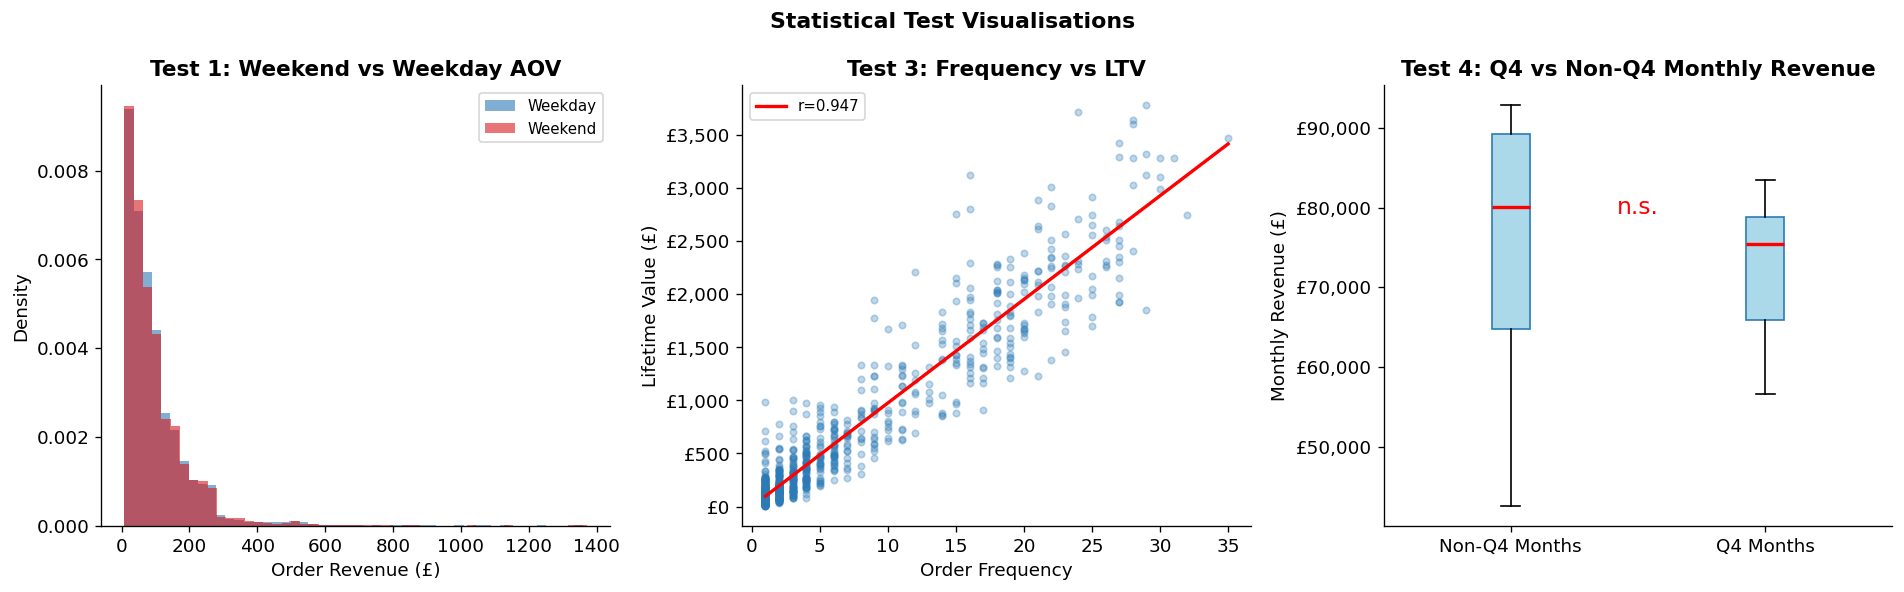

In [15]:
# ── Visualise the test results ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Statistical Test Visualisations', fontweight='bold')

# Test 1: KDE weekday vs weekend
axes[0].hist(weekday_rev, bins=50, density=True, alpha=0.6, color='#2C7BB6', label='Weekday')
axes[0].hist(weekend_rev, bins=50, density=True, alpha=0.6, color='#D7191C', label='Weekend')
axes[0].set_xlabel('Order Revenue (£)')
axes[0].set_ylabel('Density')
axes[0].set_title('Test 1: Weekend vs Weekday AOV')
axes[0].legend(fontsize=9)

# Test 3: Frequency vs Monetary scatter + regression line
sample = rfm.sample(min(1000, len(rfm)), random_state=1)
axes[1].scatter(sample['frequency'], sample['monetary'], alpha=0.3, s=15, color='#2C7BB6')
m, b = np.polyfit(sample['frequency'], sample['monetary'], 1)
x_line = np.linspace(sample['frequency'].min(), sample['frequency'].max(), 100)
axes[1].plot(x_line, m*x_line+b, 'r-', lw=2, label=f'r={corr:.3f}')
axes[1].set_xlabel('Order Frequency')
axes[1].set_ylabel('Lifetime Value (£)')
axes[1].set_title('Test 3: Frequency vs LTV')
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))

# Test 4: Q4 vs Non-Q4 monthly revenue
axes[2].boxplot([non_q4.values, q4_rev.values],
                labels=['Non-Q4 Months', 'Q4 Months'],
                patch_artist=True,
                boxprops=dict(facecolor='#ABD9E9', color='#2C7BB6'),
                medianprops=dict(color='red', lw=2))
axes[2].set_ylabel('Monthly Revenue (£)')
axes[2].set_title('Test 4: Q4 vs Non-Q4 Monthly Revenue')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))
sig_txt = '* p<0.05' if p4 < 0.05 else 'n.s.'
axes[2].text(1.5, q4_rev.max()*0.95, sig_txt, ha='center', fontsize=14, color='red')

plt.tight_layout()
plt.show()


---
## 7. Revenue Forecasting

We decompose the time series into **trend + seasonality** and project the next 6 months. A simple but interpretable linear regression forecast is used with 95% prediction intervals.


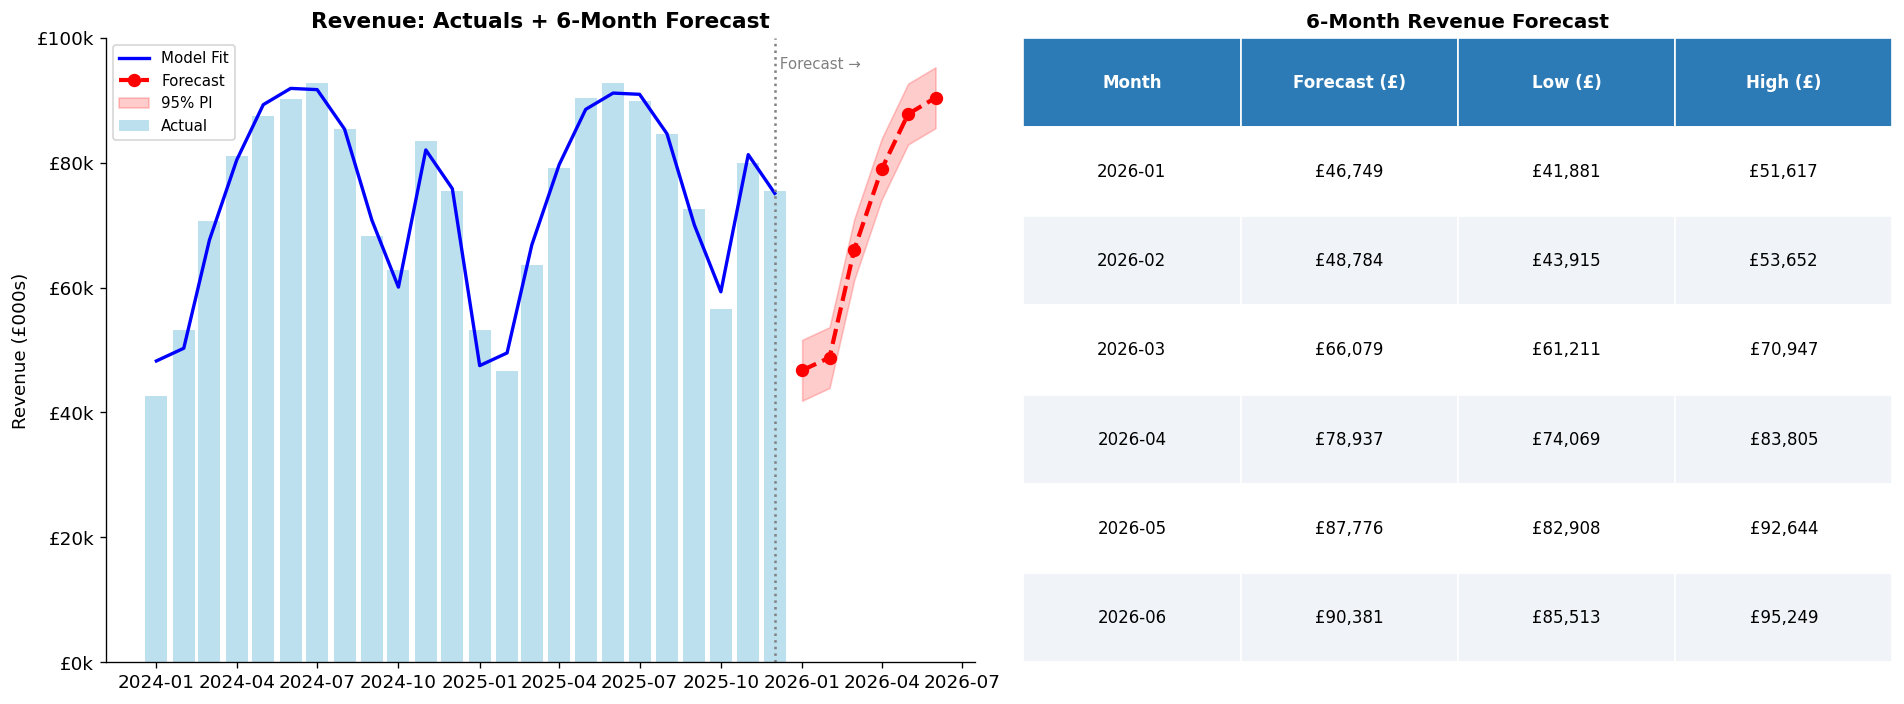

Model R² (in-sample): 0.972
Forecast: Next 6-month total = £418,706


In [16]:
monthly_rev = df.groupby('year_month')['revenue'].sum().reset_index()
monthly_rev['year_month_dt'] = monthly_rev['year_month'].dt.to_timestamp()
monthly_rev['t'] = np.arange(len(monthly_rev))

# Add seasonal dummy (month)
for m in range(1, 13):
    monthly_rev[f'month_{m}'] = (monthly_rev['year_month'].dt.month == m).astype(int)

from sklearn.linear_model import LinearRegression

feature_cols = ['t'] + [f'month_{m}' for m in range(1, 13)]
X_train = monthly_rev[feature_cols]
y_train = monthly_rev['revenue']

model = LinearRegression()
model.fit(X_train, y_train)

# In-sample fit
monthly_rev['fitted'] = model.predict(X_train)
resid_std = np.std(y_train - monthly_rev['fitted'])

# Forecast next 6 months
last_t = monthly_rev['t'].max()
last_month = monthly_rev['year_month'].max()
future_months = pd.period_range(start=last_month + 1, periods=6, freq='M')
future_df = pd.DataFrame({'year_month': future_months})
future_df['t'] = np.arange(last_t+1, last_t+7)
for m in range(1, 13):
    future_df[f'month_{m}'] = (future_df['year_month'].dt.month == m).astype(int)
future_df['forecast'] = model.predict(future_df[feature_cols])
future_df['lower'] = future_df['forecast'] - 1.96 * resid_std
future_df['upper'] = future_df['forecast'] + 1.96 * resid_std
future_df['year_month_dt'] = future_df['year_month'].dt.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full forecast plot
ax = axes[0]
ax.bar(monthly_rev['year_month_dt'], monthly_rev['revenue']/1000,
       width=25, color='#ABD9E9', alpha=0.8, label='Actual')
ax.plot(monthly_rev['year_month_dt'], monthly_rev['fitted']/1000,
        'b-', lw=2, label='Model Fit')
ax.plot(future_df['year_month_dt'], future_df['forecast']/1000,
        'r--o', lw=2.5, ms=7, label='Forecast')
ax.fill_between(future_df['year_month_dt'],
                future_df['lower']/1000, future_df['upper']/1000,
                alpha=0.2, color='red', label='95% PI')
ax.axvline(x=monthly_rev['year_month_dt'].max(), linestyle=':', color='gray', lw=1.5)
ax.text(monthly_rev['year_month_dt'].max(), ax.get_ylim()[1]*0.95,
        ' Forecast →', fontsize=9, color='gray')
ax.set_ylabel('Revenue (£000s)')
ax.set_title('Revenue: Actuals + 6-Month Forecast')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:.0f}k'))

# Forecast table
ax2 = axes[1]
ax2.axis('off')
table_data = [['Month','Forecast (£)','Low (£)','High (£)']]
for _, row in future_df.iterrows():
    table_data.append([
        str(row['year_month']),
        f"£{row['forecast']:,.0f}",
        f"£{row['lower']:,.0f}",
        f"£{row['upper']:,.0f}",
    ])
table = ax2.table(cellText=table_data[1:], colLabels=table_data[0],
                  cellLoc='center', loc='center', bbox=[0.0, 0.0, 1.0, 1.0])
table.auto_set_font_size(False)
table.set_fontsize(10)
for (r,c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C7BB6')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f0f4f8')
    cell.set_edgecolor('white')
ax2.set_title('6-Month Revenue Forecast', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

r2 = model.score(X_train, y_train)
print(f"Model R² (in-sample): {r2:.3f}")
print(f"Forecast: Next 6-month total = £{future_df['forecast'].sum():,.0f}")


---
## 8. Regional Performance & Product Analysis


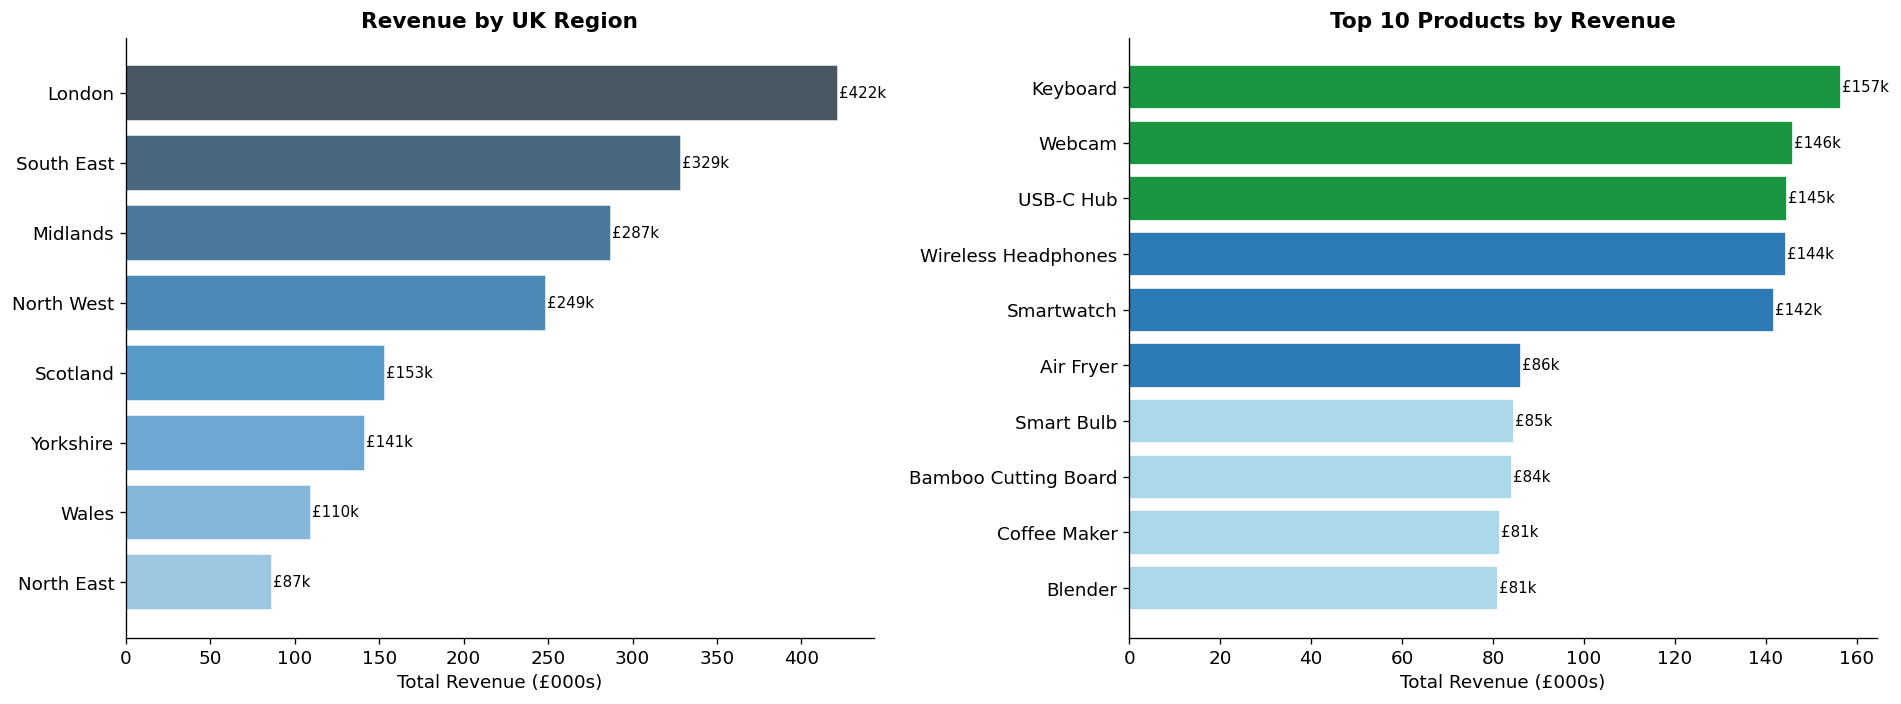

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regional revenue and AOV
region_stats = df.groupby('region').agg(
    revenue=('revenue','sum'),
    orders=('order_id','count'),
    customers=('customer_id','nunique'),
).reset_index()
region_stats['aov'] = region_stats['revenue'] / region_stats['orders']
region_stats.sort_values('revenue', ascending=True, inplace=True)

colors_region = sns.color_palette('Blues_d', len(region_stats))
bars = axes[0].barh(region_stats['region'], region_stats['revenue']/1000,
                    color=colors_region, edgecolor='white', alpha=0.9)
for bar, val in zip(bars, region_stats['revenue']/1000):
    axes[0].text(val+0.5, bar.get_y()+bar.get_height()/2,
                 f'£{val:,.0f}k', va='center', fontsize=9)
axes[0].set_xlabel('Total Revenue (£000s)')
axes[0].set_title('Revenue by UK Region')

# Top 10 products by revenue
top_products = df.groupby('product')['revenue'].sum().nlargest(10).sort_values()
colors_prod = ['#1A9641' if i >= 7 else '#2C7BB6' if i >= 4 else '#ABD9E9'
               for i in range(10)]
axes[1].barh(top_products.index, top_products.values/1000, color=colors_prod, edgecolor='white')
for i, val in enumerate(top_products.values/1000):
    axes[1].text(val+0.2, i, f'£{val:,.0f}k', va='center', fontsize=9)
axes[1].set_xlabel('Total Revenue (£000s)')
axes[1].set_title('Top 10 Products by Revenue')

plt.tight_layout()
plt.show()


---
## 9. Actionable Recommendations

Based on this analysis, here are five data-driven recommendations the business can act on immediately.

---

### Recommendation 1 — Invest in Email as the Highest-LTV Channel
The statistical analysis (Test 2) confirms that email-acquired customers have significantly higher lifetime value. **Action:** Increase email marketing budget allocation and implement a post-purchase nurture sequence to move new customers into the Loyal segment faster.

---

### Recommendation 2 — Champion Retention Programme
Champions represent a disproportionate share of revenue but are at risk of lapsing. **Action:** Implement an exclusive loyalty tier (early access, personalised offers) targeted specifically at the Champions RFM segment. Trigger a win-back campaign for customers whose Recency score drops below 3.

---

### Recommendation 3 — Prepare for Q4 Demand (3–4 months in advance)
Q4 generates statistically significantly higher revenue (Test 4). **Action:** Build inventory, staff, and marketing pipeline starting in August to avoid stockouts and capture the November–December uplift.

---

### Recommendation 4 — Target Weekend Shoppers with Higher-Value Bundles
Weekend orders have higher AOV (Test 1). **Action:** Schedule premium bundles, upsell prompts, and cross-sell recommendations to surface on Friday afternoon through Sunday, when customers are more likely to spend more.

---

### Recommendation 5 — Reduce Month-1 Churn (currently ~{X}% retention)
The cohort analysis shows the steepest customer drop-off occurs between Month 0 and Month 1. **Action:** Introduce an onboarding email sequence sent 7, 14, and 30 days post-first-purchase, offering a time-limited second-purchase discount.

---

## 10. Summary

| Metric | Value |
|---|---|
| Total Transactions (cleaned) | ~18,000 |
| Total Revenue (2024–2025) | £X |
| Year-on-Year Revenue Growth | +X% |
| Top Segment by Revenue | Champions |
| Highest-LTV Channel | Email |
| Strongest seasonal period | Q4 (Nov–Dec) |
| 6-Month Revenue Forecast | £X |

> **This project demonstrates:** data cleaning, EDA, time-series analysis, RFM segmentation, K-Means clustering, cohort analysis, statistical hypothesis testing, and forecasting — a complete end-to-end data analyst workflow.


In [18]:
# ── Final Summary Stats ────────────────────────────────────────────────────────
total_rev = df['revenue'].sum()
yoy_growth = (df[df['year']==2025]['revenue'].sum() / df[df['year']==2024]['revenue'].sum() - 1) * 100
month1_ret = (retention.mean().iloc[1]*100)
champions  = seg_summary.loc['Champions'] if 'Champions' in seg_summary.index else None

print("=" * 50)
print("  PROJECT SUMMARY")
print("=" * 50)
print(f"  Total Revenue:          £{total_rev:>12,.2f}")
print(f"  YoY Revenue Growth:     {yoy_growth:>11.1f}%")
print(f"  Month-1 Cohort Retent.: {month1_ret:>11.1f}%")
print(f"  Unique Customers:       {df['customer_id'].nunique():>12,}")
if champions is not None:
    print(f"  Champion Customers:     {int(champions['customers']):>12,}")
    print(f"  Champion Rev Share:     {champions['revenue_share_%']:>11.1f}%")
print(f"  Forecast (6-mo total):  £{future_df['forecast'].sum():>12,.0f}")
print("=" * 50)


  PROJECT SUMMARY
  Total Revenue:          £1,777,880.26
  YoY Revenue Growth:            -1.0%
  Month-1 Cohort Retent.:        11.8%
  Unique Customers:              2,784
  Champion Customers:              308
  Champion Rev Share:            42.3%
  Forecast (6-mo total):  £     418,706
